<a href="https://colab.research.google.com/github/zer0punch/zer0punch/blob/practice_1/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задача 1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv("fake_news.csv")
texts = df["text"].astype(str)
labels = df["label"]

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=5
)

X_train = vectorizer.fit_transform(X_train_texts)
X_test = vectorizer.transform(X_test_texts)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

clf = PassiveAggressiveClassifier(
    C=1.0,
    max_iter=1000,
    loss="hinge"
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Train shape: (5068, 21694)
Test shape: (1267, 21694)
Accuracy: 0.9463299131807419
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       633
        REAL       0.95      0.94      0.95       634

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267



### Матрица ошибок

<Figure size 500x500 with 0 Axes>

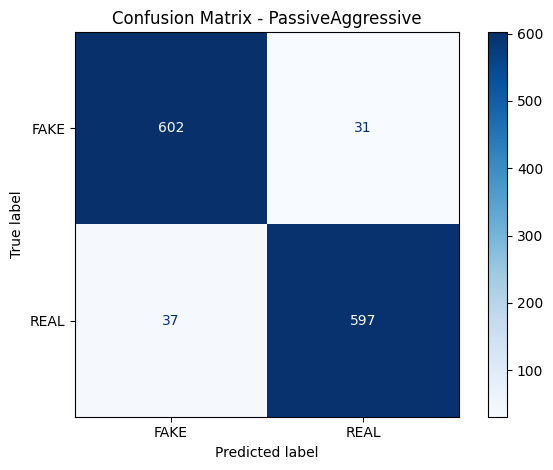

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)

plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - PassiveAggressive")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


### Визуализация самых важных признаков

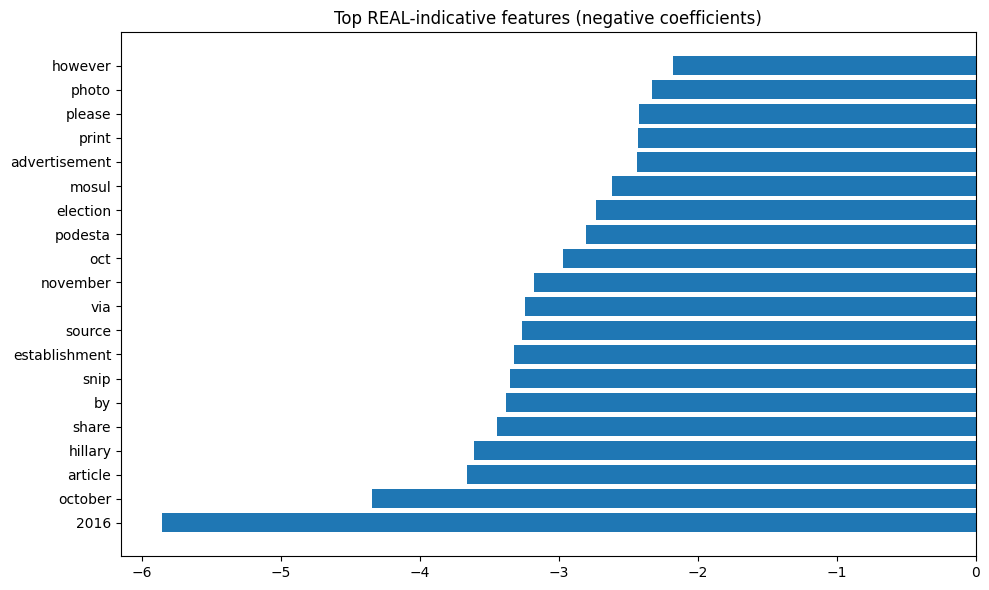

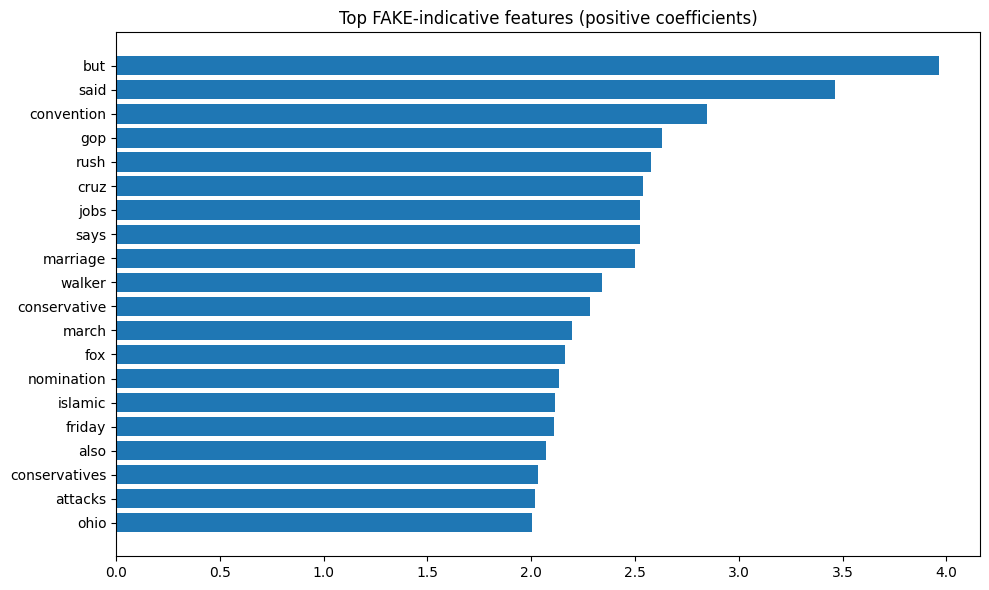

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

def plot_top_features(coefs, feature_names, top_n=20):
    top_fake_idx = np.argsort(coefs)[-top_n:]
    top_real_idx = np.argsort(coefs)[:top_n]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), coefs[top_real_idx], align="center")
    plt.yticks(range(top_n), feature_names[top_real_idx])
    plt.title("Top REAL-indicative features (negative coefficients)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), coefs[top_fake_idx], align="center")
    plt.yticks(range(top_n), feature_names[top_fake_idx])
    plt.title("Top FAKE-indicative features (positive coefficients)")
    plt.tight_layout()
    plt.show()

plot_top_features(coefs, feature_names, top_n=20)

### Задача 2

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

data = pd.read_csv("parkinsons.data")
print(data.head())
print(data.columns)

X = data.drop(columns=["name", "status"])
y = data["status"]


             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # чтобы класс-баланс сохранился
)


### Обучение классификатора

In [4]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

### Проверка качества

In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39

ROC-AUC: 0.9896551724137931


### Важность признаков

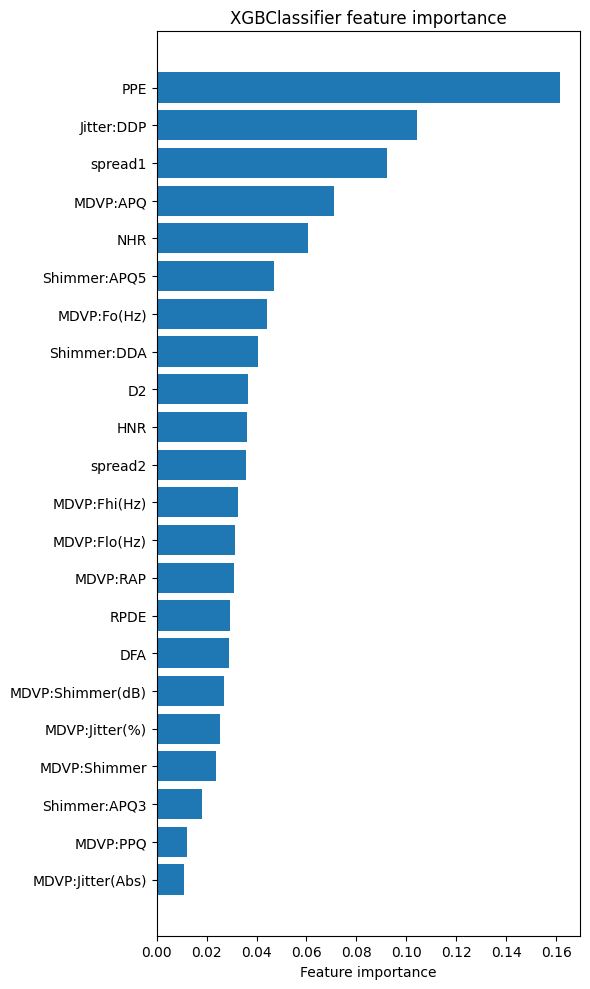

In [6]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_names = X.columns

sorted_idx = importances.argsort()

plt.figure(figsize=(6, 10))
plt.barh(feat_names[sorted_idx], importances[sorted_idx])
plt.xlabel("Feature importance")
plt.title("XGBClassifier feature importance")
plt.tight_layout()
plt.show()






*   PPE (Pitch Period Entropy) — самый сильный предиктор.
Это показатель нестабильности вибрации голоса. У пациентов с болезнью Паркинсона вибрация становится менее регулярной.
*   Jitter и Shimmer измеряют микровариации частоты и амплитуды голоса. Это ключевые биомаркеры, потому что у больных чаще наблюдаются тремор и нестабильность голосовых связок.
*   NHR (Noise-to-Harmonics Ratio) — уровень шума в голосе. Увеличение шума — признак слабости голосовых связок.

В целом, XGBoost ориентируется на признаки, типичные для классической диагностики Паркинсона.





### SHAP summary

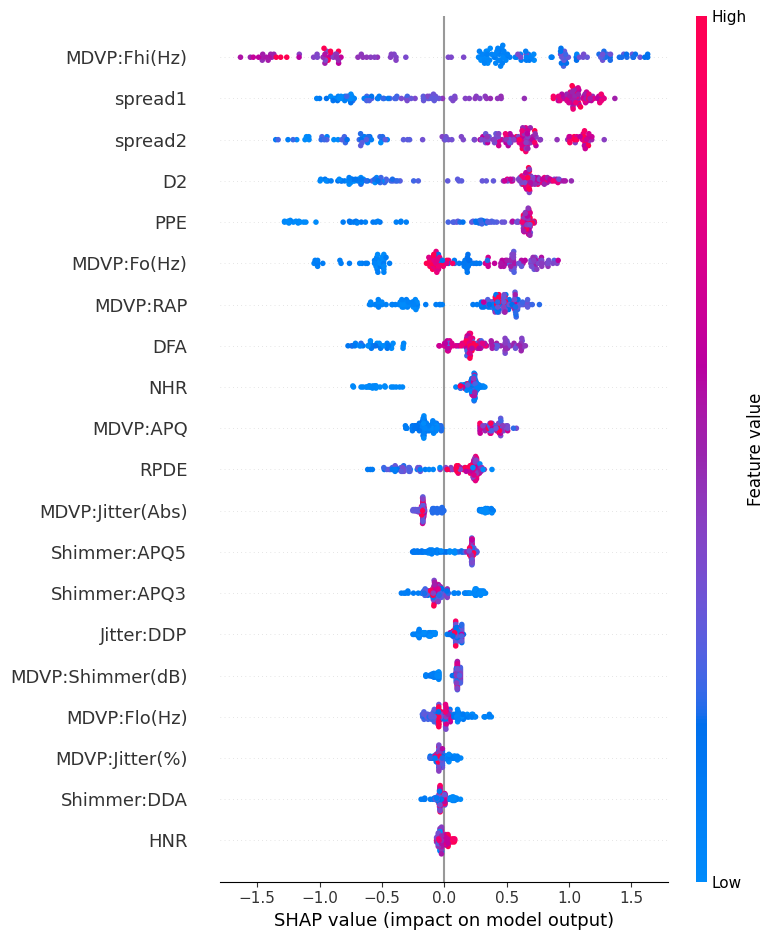

In [7]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)

Результат отличается от простого анализа важности признаков, поскольку SHAP рассматривает реальное влияение на предсказание. Итак:
1. MDVP:Fhi(Hz) (максимальная частота).
  Высокие значения (красный) часто тянут предсказание в сторону болезни → SHAP > 0. Низкие значения (синий) чаще тянут в сторону здоровья. Это означает, что у пациентов с Паркинсоном максимальная частота голоса становится нестабильной и скачкообразной.
2. spread1 и spread2. Высокие значения (красный)устойчиво ведут к положительному классу (болезнь). Низкие значения — к здоровью.
3. PPE. SHAP показывает, что PPE действительно даёт большой вклад, но только для части наблюдений, где значения очень высокие.
4. NHR, Shimmer. Их вклад оказался не таким сильным или же они сильно коррелируют друг с другом.